# French Real Estate Market Intelligence
### DVF Price Benchmarking Across 166 Calvados Communes, 2023-2025

This notebook analyses the French real estate market by delivering a price benchmark by commune for Calvados, using three years of real government data (2023, 2024 and 2025).

# Step 1: Download three years of data

In [4]:
import urllib.request, gzip, shutil

years = [2023, 2024, 2025]
for year in years:
    url = f"https://files.data.gouv.fr/geo-dvf/latest/csv/{year}/departements/14.csv.gz"
    urllib.request.urlretrieve(url, f"14_{year}.csv.gz")
    with gzip.open(f"14_{year}.csv.gz", 'rb') as f_in:
        with open(f"14_{year}.csv", 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)
    print(f"Downloaded 14_{year}.csv")

Downloaded 14_2023.csv
Downloaded 14_2024.csv
Downloaded 14_2025.csv


# Step 2: Load and combine the three years

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

dfs = [pd.read_csv(f"14_{y}.csv", sep=',', encoding='utf-8', low_memory=False) for y in [2023, 2024, 2025]]
df = pd.concat(dfs, ignore_index=True)

print(f"Combined: {df.shape[0]:,} rows across {df['date_mutation'].str[:4].nunique()} years")

Combined: 142,296 rows across 3 years


# Step 3: Check the real category names before filtering



Do not copy filter strings from memory or from any template. Print the real values first, every time, on every new department, because accented French text is easy to get wrong silently.

In [9]:
print(df['type_local'].value_counts(dropna=False))
print()
print(repr(df['nature_mutation'].unique()))

type_local
NaN                                         48543
Dépendance                                  44760
Maison                                      28540
Appartement                                 16425
Local industriel. commercial ou assimilé     4028
Name: count, dtype: int64

<StringArray>
[                             'Vente', 'Vente en l'état futur d'achèvement',
              'Vente terrain à bâtir',                            'Echange',
                       'Adjudication']
Length: 5, dtype: str


Copy the exact strings you see here into Step 4. If they don't match what's below, use what you actually see.

# Step 4: Clean the data

In [12]:
df_clean = df.copy()

# paste the exact accented strings from Step 3 here
valid_mutations = ["Vente", "Vente en l'état futur d'achèvement"]
df_clean = df_clean[df_clean['nature_mutation'].isin(valid_mutations)]

valid_types = ["Appartement", "Maison"]
df_clean = df_clean[df_clean['type_local'].isin(valid_types)]

df_clean = df_clean.dropna(subset=['valeur_fonciere', 'surface_reelle_bati'])
df_clean = df_clean[(df_clean['valeur_fonciere'] > 0) & (df_clean['surface_reelle_bati'] > 0)]

df_clean['date_mutation'] = pd.to_datetime(df_clean['date_mutation'], errors='coerce')
df_clean['annee'] = df_clean['date_mutation'].dt.year

print(f"After filtering: {df_clean.shape[0]:,} sales")

After filtering: 44,704 sales


# Step 5: Remove duplicate transactions



One sale (id_mutation) can appear on several rows when it covers several lots, and each row repeats the full sale price. Keep one row per sale, the one with the largest surface, so you don't count the same sale twice.

In [15]:
print(f"Before dedup: {len(df_clean):,} rows, {df_clean['id_mutation'].nunique():,} unique sales")

df_clean = df_clean.sort_values('surface_reelle_bati', ascending=False)
df_clean = df_clean.drop_duplicates(subset='id_mutation', keep='first')
df_clean['prix_m2'] = df_clean['valeur_fonciere'] / df_clean['surface_reelle_bati']

print(f"After dedup: {len(df_clean):,} rows")

Before dedup: 44,704 rows, 34,000 unique sales
After dedup: 34,000 rows


# Step 6: Remove price outliers


In [17]:
def remove_outliers_iqr(dataframe, column, group_col='type_local'):
    df_out = pd.DataFrame()
    for group_name, group_df in dataframe.groupby(group_col):
        Q1 = group_df[column].quantile(0.25)
        Q3 = group_df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = max(Q1 - 1.5 * IQR, 500)
        upper_bound = Q3 + 1.5 * IQR
        filtered = group_df[(group_df[column] >= lower_bound) & (group_df[column] <= upper_bound)]
        df_out = pd.concat([df_out, filtered], ignore_index=True)
        print(f"{group_name}: kept {len(filtered):,} / {len(group_df):,}")
    return df_out

df_clean = remove_outliers_iqr(df_clean, 'prix_m2')
print(f"\nFinal dataset: {df_clean.shape[0]:,} transactions")

Appartement: kept 13,607 / 14,225
Maison: kept 18,295 / 19,775

Final dataset: 31,902 transactions


Why IQR, if a client asks: it uses percentiles, so a handful of very expensive properties don't distort the cutoff, unlike a method based on the average.

# Step 7: Build the commune benchmark table



In [20]:
MIN_TRANSACTIONS = 30

commune_stats = (
    df_clean.groupby(['nom_commune', 'type_local'])
    .agg(
        transactions=('prix_m2', 'count'),
        prix_m2_median=('prix_m2', 'median'),
        surface_median=('surface_reelle_bati', 'median'),
    )
    .reset_index()
)
commune_stats = commune_stats[commune_stats['transactions'] >= MIN_TRANSACTIONS]

dept_median_appart = df_clean[df_clean['type_local'] == 'Appartement']['prix_m2'].median()
dept_median_maison = df_clean[df_clean['type_local'] == 'Maison']['prix_m2'].median()

def add_benchmark(row):
    ref = dept_median_appart if row['type_local'] == 'Appartement' else dept_median_maison
    row['ecart_dept_pct'] = ((row['prix_m2_median'] - ref) / ref) * 100
    return row

commune_stats = commune_stats.apply(add_benchmark, axis=1).round(2)
commune_stats.to_csv("commune_benchmark_calvados.csv", index=False, encoding='utf-8-sig')
print(f"Communes in the table: {commune_stats['nom_commune'].nunique()}")

Communes in the table: 166


Note: Calvados has fewer transactions than a big city department. If very few communes clear the 30-transaction bar, that's the threshold working correctly, not a bug. You can lower it to 20 and say so openly in the report if the table comes out too thin.

# Step 8: Four charts



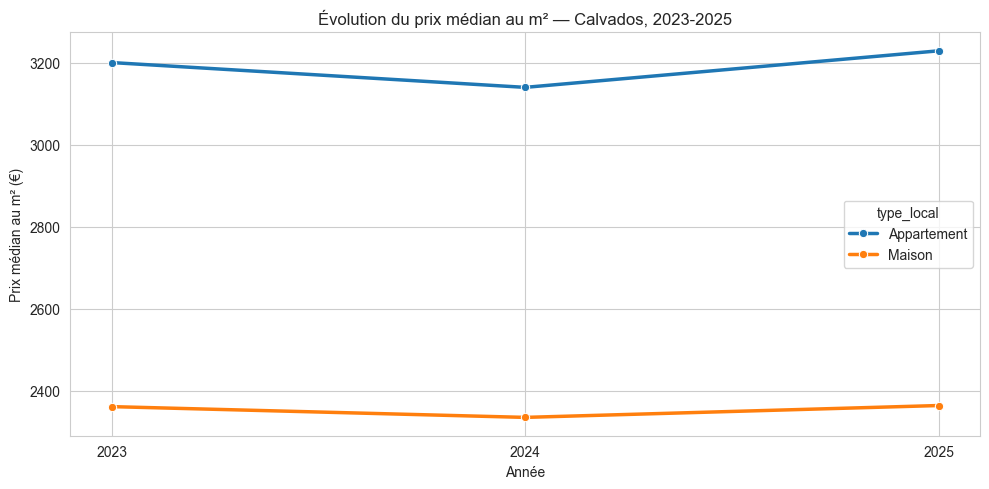

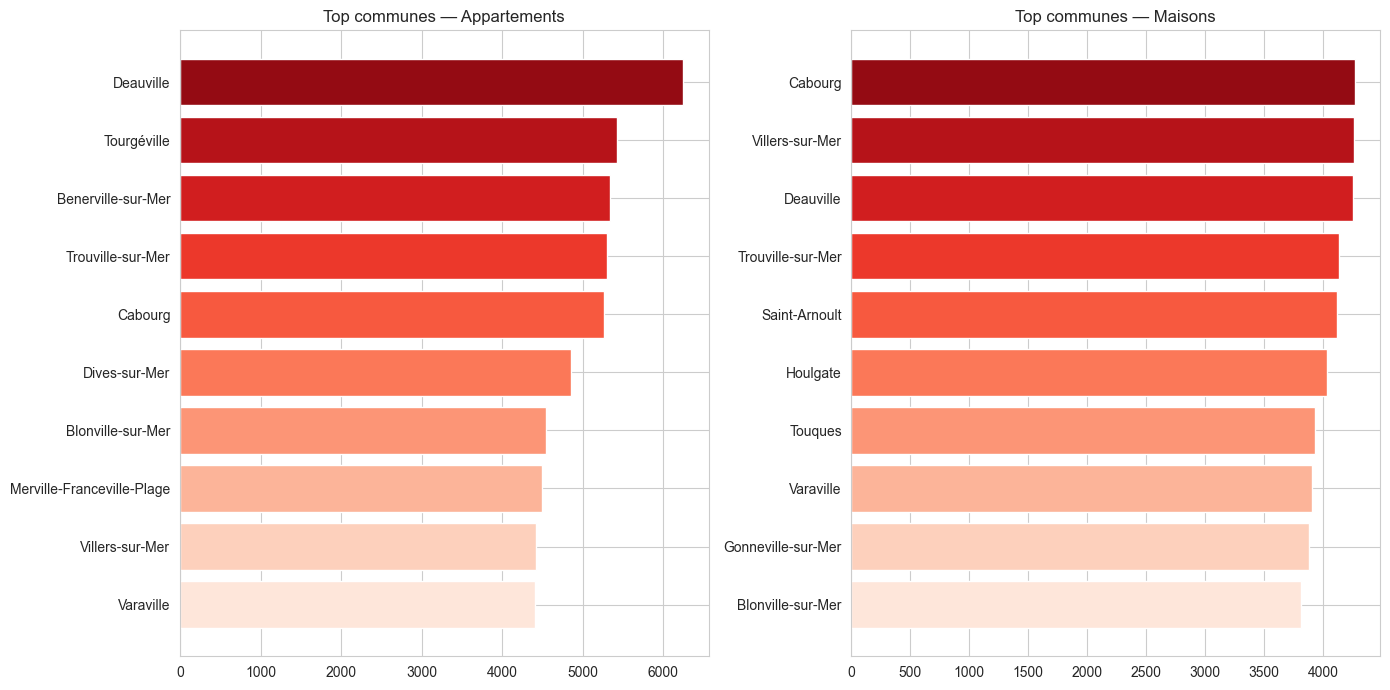

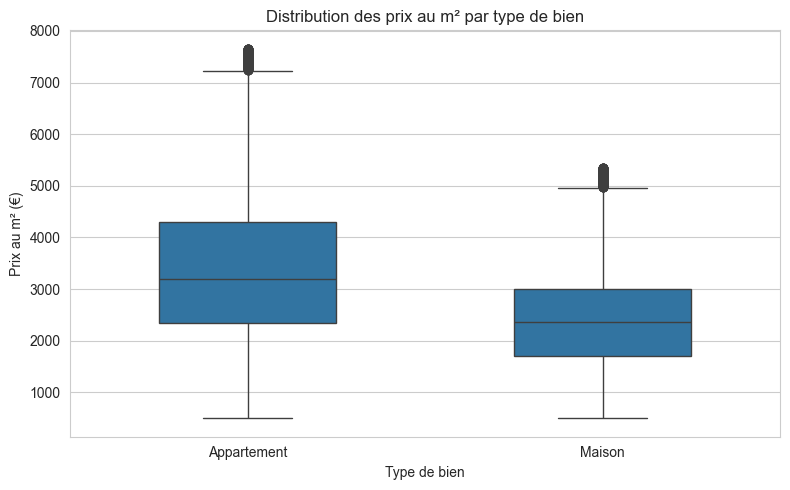

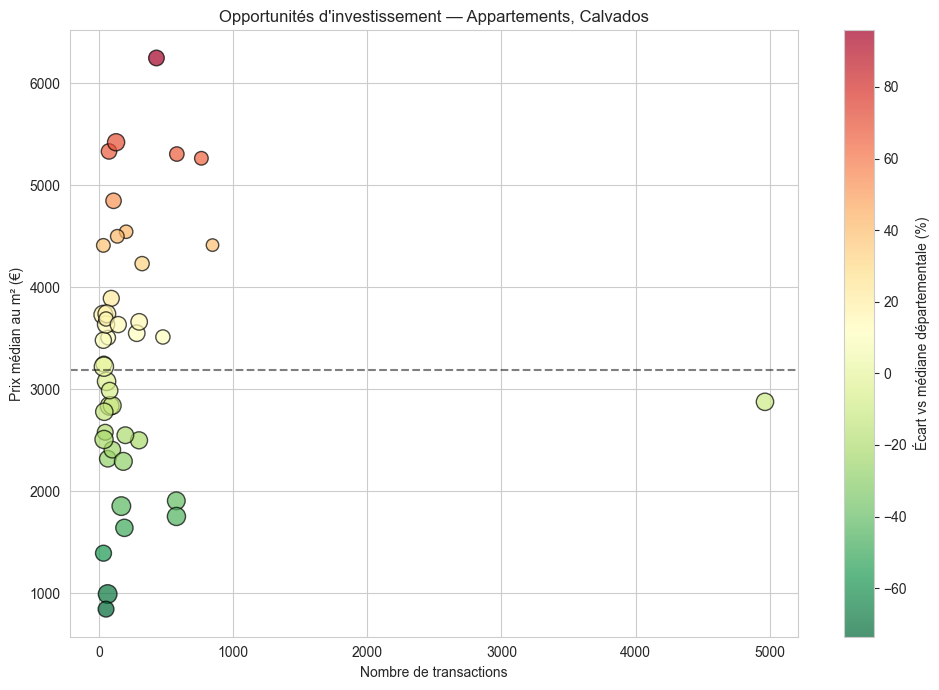

In [23]:
# Chart 1: real price trend, now valid because you have 3 years
time_series = df_clean.groupby(['annee', 'type_local'])['prix_m2'].median().reset_index()
plt.figure(figsize=(10, 5))
sns.lineplot(data=time_series, x='annee', y='prix_m2', hue='type_local', marker='o', linewidth=2.5)
plt.title('Évolution du prix médian au m² — Calvados, 2023-2025')
plt.xlabel('Année'); plt.ylabel('Prix médian au m² (€)')
plt.xticks([2023, 2024, 2025])
plt.tight_layout(); plt.savefig("chart1_evolution.png", dpi=150); plt.show()

# Chart 2: top communes, horizontal bars
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for idx, ptype in enumerate(['Appartement', 'Maison']):
    ax = axes[idx]
    data = commune_stats[commune_stats['type_local'] == ptype].nlargest(10, 'prix_m2_median')
    ax.barh(data['nom_commune'], data['prix_m2_median'], color=sns.color_palette("Reds_r", len(data)))
    ax.invert_yaxis()
    ax.set_title(f'Top communes — {ptype}s')
plt.tight_layout(); plt.savefig("chart2_top_communes.png", dpi=150); plt.show()

# Chart 3: price distribution
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x='type_local', y='prix_m2', width=0.5)
plt.title('Distribution des prix au m² par type de bien')
plt.xlabel('Type de bien')
plt.ylabel('Prix au m² (€)')
plt.tight_layout(); plt.savefig("chart3_distribution.png", dpi=150); plt.show()

# Chart 4: volume vs price bubble chart
scatter_data = commune_stats[commune_stats['type_local'] == 'Appartement']
plt.figure(figsize=(10, 7))
sc = plt.scatter(scatter_data['transactions'], scatter_data['prix_m2_median'],
                  s=scatter_data['surface_median'] * 3, c=scatter_data['ecart_dept_pct'],
                  cmap='RdYlGn_r', alpha=0.7, edgecolors='black')
plt.colorbar(sc, label='Écart vs médiane départementale (%)')
plt.axhline(dept_median_appart, color='black', linestyle='--', alpha=0.5)
plt.title("Opportunités d'investissement — Appartements, Calvados")
plt.xlabel('Nombre de transactions'); plt.ylabel('Prix médian au m² (€)')
plt.tight_layout(); plt.savefig("chart4_investment_map.png", dpi=150); plt.show()

# Step 9: Executive summary



In [25]:
total = len(df_clean)
top = commune_stats[commune_stats['type_local'] == 'Appartement'].nlargest(1, 'prix_m2_median').iloc[0]
bottom = commune_stats[commune_stats['type_local'] == 'Appartement'].nsmallest(1, 'prix_m2_median').iloc[0]

summary = f"""
RAPPORT DE MARCHÉ IMMOBILIER — CALVADOS (14), 2023-2025
Transactions analysées : {total:,} ventes résidentielles
Prix médian appartements : {dept_median_appart:,.0f} €/m²
Prix médian maisons : {dept_median_maison:,.0f} €/m²
Commune la plus chère : {top['nom_commune']} ({top['prix_m2_median']:,.0f} €/m²)
Commune la plus accessible : {bottom['nom_commune']} ({bottom['prix_m2_median']:,.0f} €/m²)
Méthodologie : DVF (DGFiP), filtrage IQR, déduplication par transaction, médianes
"""
print(summary)
with open("executive_summary_calvados.txt", "w", encoding='utf-8') as f:
    f.write(summary)


RAPPORT DE MARCHÉ IMMOBILIER — CALVADOS (14), 2023-2025
Transactions analysées : 31,902 ventes résidentielles
Prix médian appartements : 3,192 €/m²
Prix médian maisons : 2,355 €/m²
Commune la plus chère : Deauville (6,250 €/m²)
Commune la plus accessible : Sommervieu (844 €/m²)
Méthodologie : DVF (DGFiP), filtrage IQR, déduplication par transaction, médianes

